In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

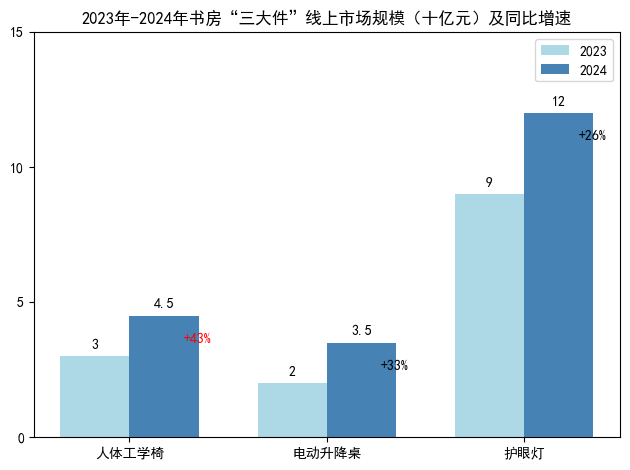

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 类别
categories = ["人体工学椅", "电动升降桌", "护眼灯"]
# 2023 年数据（十亿元）
values_2023 = [3, 2, 9]  
# 2024 年数据（十亿元）
values_2024 = [4.5, 3.5, 12]  
# 同比增速
growth_rates = ["+43%", "+33%", "+26%"]  

x = np.arange(len(categories))  # x 轴位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots()
# 绘制 2023 年柱状图
rects2023 = ax.bar(x - width/2, values_2023, width, label='2023', color='lightblue')  
# 绘制 2024 年柱状图
rects2024 = ax.bar(x + width/2, values_2024, width, label='2024', color='steelblue')  

# 添加数值标注函数
def add_labels(rects, values):
    for rect, value in zip(rects, values):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.2,
                f'{value}', ha='center', va='bottom')

# 为两个年份的柱状图添加数值标注
add_labels(rects2023, values_2023)
add_labels(rects2024, values_2024)

# 添加同比增速文本
for i in range(len(categories)):
    if growth_rates[i].startswith('+'):
        arrow_color = 'red' if growth_rates[i] == '+43%' else 'black'
        ax.text(x[i] + width/2 + 0.1, values_2024[i] - 1, growth_rates[i], 
                color=arrow_color, fontweight='bold')
    else:
        ax.text(x[i] + width/2, values_2024[i] + 0.2, growth_rates[i], ha='center')

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(categories)
# 设置 y 轴范围，留出标注空间
ax.set_ylim([0, 15])  
# 添加 y 轴刻度
ax.set_yticks(np.arange(0, 16, 5))  
# 添加图例
ax.legend()

# 设置图表标题
ax.set_title('2023年-2024年书房“三大件”线上市场规模（十亿元）及同比增速')
plt.tight_layout()  # 确保布局合理
plt.show()

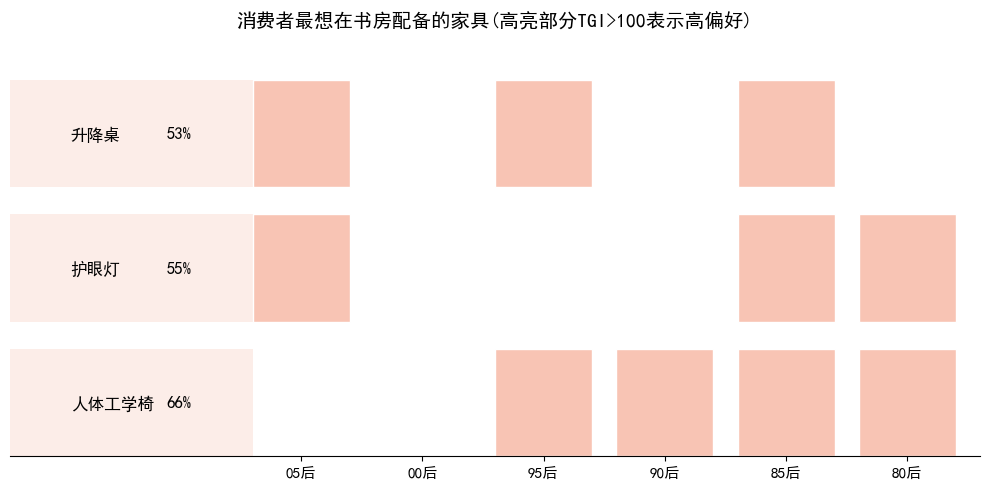

In [3]:
import matplotlib.pyplot as plt

# 数据 - 按图表顺序：人体工学椅、护眼灯、升降桌；代际顺序 05后→00后→95后→90后→85后→80后
categories = ["人体工学椅", "护眼灯", "升降桌"]
generations = ["05后", "00后", "95后", "90后", "85后", "80后"]
# 1 表示有方格填充，0 表示无，与图表对应
data = {
    "人体工学椅": [0, 0, 1, 1, 1, 1],  
    "护眼灯": [1, 0, 0, 0, 1, 1],     
    "升降桌": [1, 0, 1, 0, 1, 0]      
}

# 总百分比（与图表一致）
total_percentages = {
    "人体工学椅": 66,
    "护眼灯": 55,
    "升降桌": 53
}

# 自定义颜色（贴近原图橙色系）
colors = {
    "人体工学椅": "#F8C4B4",  # 浅橙色，贴近原图人体工学椅颜色
    "护眼灯": "#F8C4B4",    # 浅橙色，护眼灯颜色
    "升降桌": "#F8C4B4"     # 浅橙色，升降桌颜色
}

# 创建画布
fig, ax = plt.subplots(figsize=(10, 5))  # 调整画布大小适配

# 设置网格参数
grid_size = 0.8   # 方格大小
spacing = 0.2     # 方格间距
label_width = 2   # 左侧标签区域宽度

# 绘制内容
for i, cat in enumerate(categories):
    # 左侧标签背景（浅橙色半透）
    rect_bg = plt.Rectangle(
        (0, i * (grid_size + spacing)),
        label_width, grid_size,
        facecolor=colors[cat],
        alpha=0.3,
        edgecolor='none'
    )
    ax.add_patch(rect_bg)
    
    # 物品名称
    ax.text(
        label_width * 0.25,  
        i * (grid_size + spacing) + grid_size/2,
        cat,
        ha='left',
        va='center',
        color='black',
        fontweight='bold',
        fontsize=12
    )
    
    # 百分比标签
    ax.text(
        label_width * 0.75,  
        i * (grid_size + spacing) + grid_size/2,
        f'{total_percentages[cat]}%',
        ha='right',
        va='center',
        color='black',
        fontweight='bold',
        fontsize=12
    )
    
    # 绘制数据方格
    for j, value in enumerate(data[cat]):
        if value == 1:  # 有值则绘制方格
            rect = plt.Rectangle(
                (label_width + j * (grid_size + spacing), i * (grid_size + spacing)),
                grid_size, grid_size,
                facecolor=colors[cat],
                edgecolor='white',
                alpha=1
            )
            ax.add_patch(rect)

# 设置坐标轴范围
ax.set_xlim(0, label_width + len(generations) * (grid_size + spacing))
ax.set_ylim(0, len(categories) * (grid_size + spacing))

# X轴标签（代际）
x_ticks = [label_width + j * (grid_size + spacing) + grid_size/2 for j in range(len(generations))]
ax.set_xticks(x_ticks)
ax.set_xticklabels(generations, fontsize=11, rotation=0)

# 标题
ax.set_title('消费者最想在书房配备的家具(高亮部分TGI>100表示高偏好)', fontsize=14, pad=20)

# 隐藏多余边框，保留X轴标签
ax.yaxis.set_visible(False)  # 隐藏Y轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 调整布局避免截断
plt.tight_layout()
plt.show()

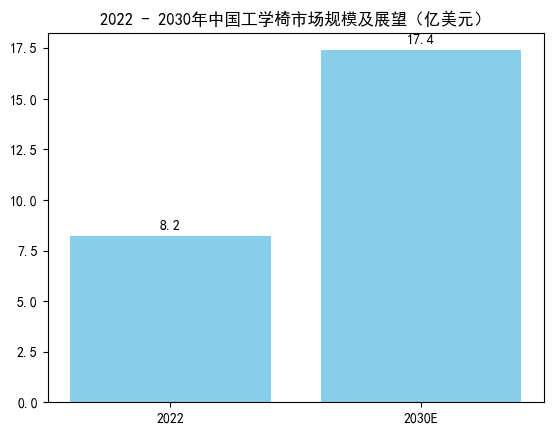

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ['2022', '2030E']
values = [8.2, 17.4]

# 用于在柱状图上方合适位置显示复合增长率，这里简单设置在两柱子中间上方
x_pos = 0.5  
y_pos = max(values) + 1  

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 绘制柱状图
ax.bar(years, values, color='skyblue')

# 添加数据标签
for x, y in zip(years, values):
    ax.text(x, y + 0.2, f'{y}', ha='center', va='bottom')

# 设置标题
ax.set_title('2022 - 2030年中国工学椅市场规模及展望（亿美元）')

# 显示图形
plt.show()

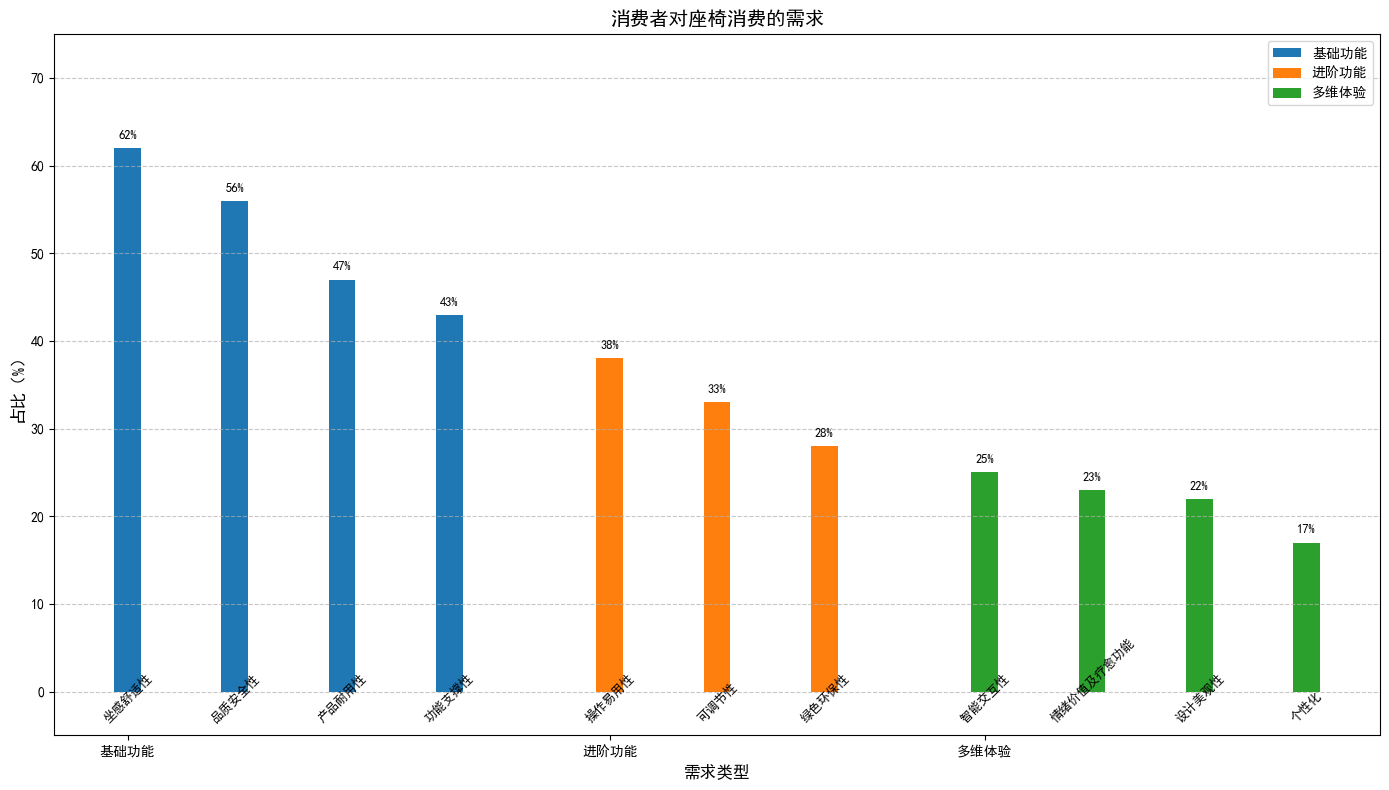

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据整理
categories = ['基础功能', '进阶功能', '多维体验']
sub_categories = {
    '基础功能': ['坐感舒适性', '品质安全性', '产品耐用性', '功能支撑性'],
    '进阶功能': ['操作易用性', '可调节性', '绿色环保性'],
    '多维体验': ['智能交互性', '情绪价值及疗愈功能', '设计美观性', '个性化']
}
values = {
    '基础功能': [62, 56, 47, 43],
    '进阶功能': [38, 33, 28],
    '多维体验': [25, 23, 22, 17]
}

# 用于设置每组条形的位置
x_positions = {}
bar_width = 0.25
spacing = 0.5  # 不同主类别之间的间距

# 动态计算每个主类别的x位置
current_x = 0
for cat in categories:
    n_sub = len(sub_categories[cat])
    x_positions[cat] = np.arange(current_x, current_x + n_sub)
    current_x += n_sub + spacing

# 创建图形
fig, ax = plt.subplots(figsize=(14, 8))  # 增加图形高度以容纳标签

# 绘制每组条形并添加百分比标签
for i, cat in enumerate(categories):
    bars = ax.bar(x_positions[cat], values[cat], width=bar_width, label=cat)
    
    # 为每个条形添加百分比标签
    for bar, value in zip(bars, values[cat]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, 
                f'{value}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 为每个主类别添加子类别标签（微调位置）
    for j, pos in enumerate(x_positions[cat]):
        ax.text(pos, -3.5, sub_categories[cat][j], ha='center', rotation=45, fontsize=9)

# 设置x轴刻度（这里我们只需要标记每个主类别的起始位置）
ax.set_xticks([x_positions[cat][0] for cat in categories])
ax.set_xticklabels(categories)

# 添加标题、图例和标签
ax.set_title('消费者对座椅消费的需求', fontsize=14)
ax.set_xlabel('需求类型', fontsize=12)
ax.set_ylabel('占比（%）', fontsize=12)
ax.legend()

# 设置y轴范围，使负值标签和数值标签可见
ax.set_ylim(bottom=-5, top=75)  # 调整y轴上限以确保标签不超出

# 添加网格线，便于读取数值
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()